In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.interpolate import interp1d
import os

In [2]:
expe_dt = [336,386,408,481,506,646]
expe_dt = [x/24. for x in expe_dt]
expe_diam = [ 1140 , 1400 , 1590 , 2040 , 2250 , 3040 ]

biodynamo_dt = [14, 14.8333333333333, 15.6666666666667, 16.5, 17.3333333333333, 18.1666666666666, 18.9999999999999, 19.8333333333332, 20.6666666666665, 21.4999999999998, 22.333333333333, 23.1666666666663, 23.9999999999996, 24.8333333333329, 25.6666666666665, 26.5]
biodynamo_diam =  [1240, 1320, 1440, 1560, 1680, 1800, 1920, 2040, 2160, 2280, 2400, 2520, 2640, 2760, 2880, 3000]

df_tsim_pre = pd.read_csv('../Tisim/use_case_2Ddisk/2D disk.csv', sep=',', engine='python')
df_tisim = pd.DataFrame({
    'dt': df_tsim_pre['time (day)'].iloc[140:],
    'diam': df_tsim_pre["diameter (um)"].iloc[140:],
    'Results': 'TiSim'
})
# df_tisim = df_tisim[df_tisim['dt'] >= 14]

with open("../Chaste/use_case_2Ddisk/results/monolayer.dat") as results_file:
    times = []
    diameter = []
    cells = []
    for line in results_file:
        line = line.replace('\n', '')
        values = re.split('\t|,', line)
        if len(values) == 1:
            continue
        
        times.append(float(values[0]))
        diameter.append(float(values[1]))
        cells.append(float(values[2]))
df_chaste = pd.DataFrame(data = zip(times,diameter,cells),columns=['dt','diam','cells'])
df_chaste["dt"]=(df_chaste["dt"])/24
df_chaste['Results'] = 'Chaste'

# Fix PhysiCell data loading - start from 14 days
df_pc = pd.read_csv('../PhysiCell/results/monolayer/monolayer_t_diam.csv', sep=',', engine='python')
df_pc = df_pc.rename(columns={df_pc.columns[0]: 'dt', df_pc.columns[1]: 'diam'})
# Filter data to start from 14 days
df_pc = df_pc[(df_pc['dt'] >= 14) & (df_pc['dt'] <= 27)]
df_pc['Results'] = 'PhysiCell'

df_exp = pd.DataFrame(data=zip(expe_dt,expe_diam),columns=['dt','diam'])
df_exp.insert(loc=2, column='Results', value='Experimental')

df_biod = pd.DataFrame(data=zip(biodynamo_dt,biodynamo_diam),columns=['dt','diam'])
df_biod.insert(loc=2, column='Results', value='BioDynaMo')

/tmp/ipykernel_13555/2622399653.py:81: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax1.plot(
/tmp/ipykernel_13555/2622399653.py:139: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax2.plot(


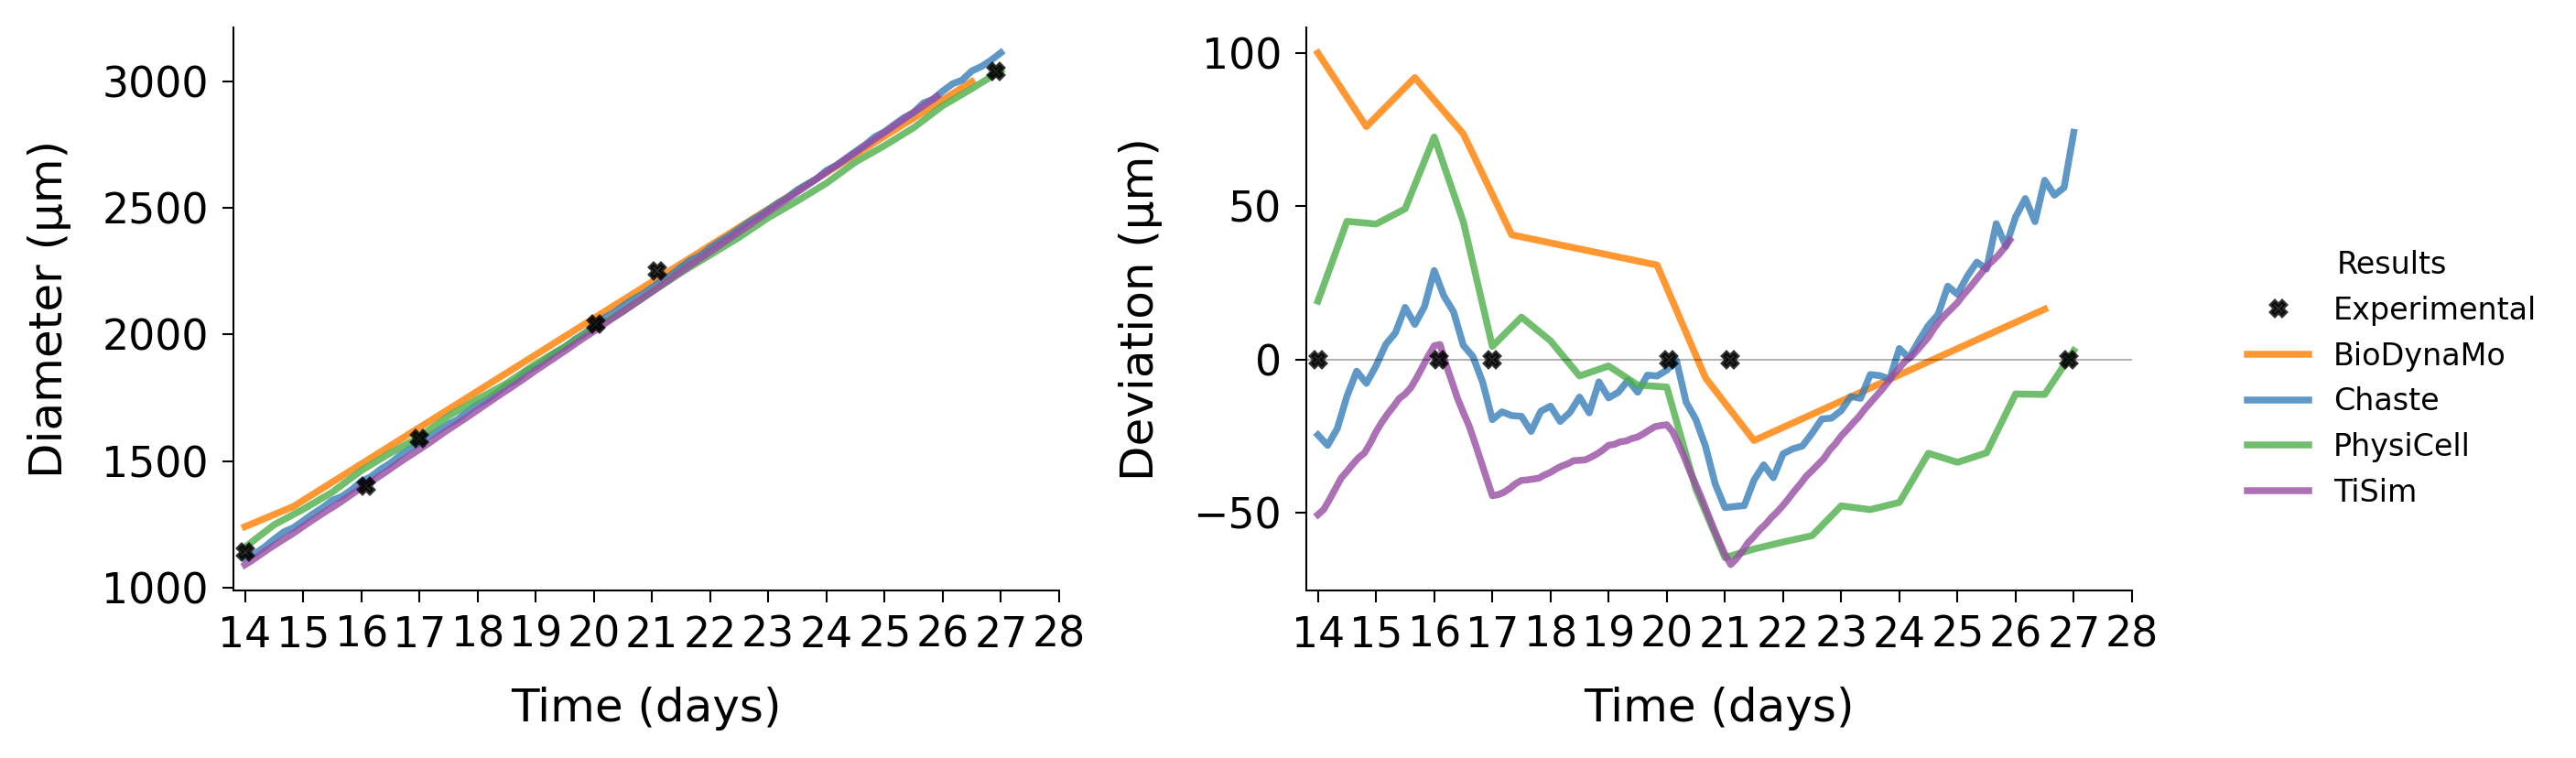

In [6]:
df_all = pd.concat([
    df_exp,  # Experimental
    df_tisim,  # TiSim
    df_chaste, # Chaste
    df_pc,    # PhysiCell
    df_biod   # BioDynaMo
], ignore_index=True)

# Remove any NaN values that might have been introduced
df_all = df_all.dropna(subset=['dt', 'diam'])

# Sort by time for better plotting
df_all = df_all.sort_values('dt')

# Print some diagnostic information
# print("\nDataFrame Info:")
# print(df_all.info())
# print("\nSample of combined data:")
# print(df_all.head())
# print("\nNumber of points per simulator:")
# print(df_all['Results'].value_counts())

# Set plotting order and color/marker mapping
results_order = ['Experimental','TiSim',  'Chaste', 'PhysiCell', 'BioDynaMo']
marker_map = {
    'Experimental': 'X'
}

# Define consistent colors and linestyles for all tools
colors = {
    'PhysiCell': '#4daf4a',   # Green
    'BioDynaMo': '#ff7f00',   # Orange
    'Chaste': '#377eb8',      # Blue
    'TiSim': '#984ea3',       # Purple
    'Experimental': '#000000' # Black
}
linestyles = {
    'PhysiCell': '-',
    'BioDynaMo': '-',
    'Chaste': '-',
    'TiSim': '-',
    'Experimental': '-'
}
linewidths = {
    'PhysiCell': 1.8,
    'BioDynaMo': 1.8,
    'Chaste': 1.8,
    'TiSim': 1.8,
    'Experimental': 2.5
}

# Set up the figure with specific dimensions (Nature's column width is 89mm)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 2.8))  # Compact, publication style

# Update font settings with fallback options
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'Arial', 'sans-serif'],  # DejaVu Sans is usually available by default
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'figure.dpi': 300
})

# Create interpolated experimental line for deviation plot
exp_times = df_exp['dt'].values
exp_diams = df_exp['diam'].values
exp_interp = interp1d(exp_times, exp_diams, kind='linear', bounds_error=False, fill_value=(exp_diams[0], exp_diams[-1]))

# First plot (original)
df_exp_plot = df_all[df_all['Results'] == 'Experimental']
ax1.plot(
    df_exp_plot['dt'], df_exp_plot['diam'], 'o',
    label='Experimental',
    # linestyle=linestyles['Experimental'],
    linewidth=linewidths['Experimental'],
    marker=marker_map.get('Experimental', None),
    markersize=4,   # Smaller markers
    markeredgecolor='k',
    markerfacecolor=colors['Experimental'],
    alpha=0.8,
    zorder=2
)

# Plot all other results
for result in ['BioDynaMo', 'Chaste', 'PhysiCell', 'TiSim']:
    df = df_all[(df_all['Results'] == result) & (df_all['dt'] <= 27)]
    ax1.plot(
        df['dt'], df['diam'],
        color=colors[result],
        label=result,
        linestyle=linestyles[result],
        linewidth=linewidths[result],
        alpha=0.8,
        zorder=1
    )

ax1.set_xlabel("Time (days)", labelpad=8, fontsize=12)
ax1.set_ylabel("Diameter (μm)", labelpad=8, fontsize=12)
ax1.set_xlim(13.8, 28)
ax1.set_xticks(np.arange(14, 29, 1))
ax1.set_ylim(bottom=df_all['diam'].min() - 100, top=df_all['diam'].max() + 100)

ax1.grid(False)
ax1.set_axisbelow(True)

# Remove top and right spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(axis='both', which='major', labelsize=11)

# Second plot (deviations)
for result in ['BioDynaMo', 'Chaste', 'PhysiCell', 'TiSim']:
    df = df_all[(df_all['Results'] == result) & (df_all['dt'] <= 27)]
    exp_values = exp_interp(df['dt'])
    deviations = df['diam'] - exp_values
    ax2.plot(
        df['dt'], 
        deviations,
        color=colors[result],
        label=result,
        linestyle=linestyles[result],
        linewidth=linewidths[result],
        alpha=0.8,
        zorder=1
    )

# Add zero line for reference
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=0.5, zorder=1)
ax2.plot(
    df_exp_plot['dt'], 
    [0, 0, 0, 0, 0, 0],  # Zero line for experimental data
    'o',
    color=colors['Experimental'],
    label='Experimental',
    # linestyle=linestyles['Experimental'],
    linewidth=linewidths['Experimental'],
    marker=marker_map.get('Experimental', None),
    markersize=4,   # Smaller markers
    markeredgecolor='k',
    markerfacecolor=colors['Experimental'],
    alpha=0.8,
    zorder=2
)

# Customize second plot
ax2.set_xlabel("Time (days)", labelpad=8, fontsize=12)
ax2.set_ylabel("Deviation (μm)", labelpad=8, fontsize=12)
ax2.set_xlim(13.8, 28)
ax2.set_xticks(np.arange(14, 29, 1))

ax2.grid(False)
ax2.set_axisbelow(True)

# Remove top and right spines
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(axis='both', which='major', labelsize=11)

# Add shared legend
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, title="Results", 
          loc='center left', bbox_to_anchor=(1.02, 0.5), 
          borderaxespad=0., frameon=False)

# Adjust layout
plt.tight_layout()


save_dir = "./"
os.makedirs(save_dir, exist_ok=True)

# Save as PDF 
# plt.savefig(os.path.join(save_dir, "monolayer_comparison_combined.pdf"), 
#             format='pdf',
#             bbox_inches='tight', 
#             pad_inches=0.1)

# Optionally, also save as SVG
# plt.savefig(os.path.join(save_dir, "monolayer_comparison_combined.svg"), 
#             format='svg',
#             bbox_inches='tight', 
#             pad_inches=0.1)

# Keep PNG for quick previews if needed
plt.savefig(os.path.join(save_dir, "monolayer_comparison_combined.png"), 
            dpi=300, 
            bbox_inches='tight', 
            pad_inches=0.1,
            format='png')
